## Import library framework

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# This EDA methods for Sales Prediction

## Read database

In [27]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("../../Database/SuperStoreOrders - SuperStoreOrders.csv")
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [29]:
# Check missing values
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

## Feature Engineering

In [30]:
# Clean data for datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

In [31]:
# Convert sales and ensure profit are numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'] = round(df['sales'], 2)
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

In [32]:
# Add column unit price feature (sales divided by quantity)
df['unit_price'] = df['sales'] / df['quantity'] # TODO: To know about unit price for each product
df['unit_price'] = round(df['unit_price'], 2)

# Add column profit margin feature (profit divided by sales)
df['profit_margin'] = df['profit'] / df['sales'] # TODO: To know about profit margin for each product
df['profit_margin'] = round(df['profit_margin'], 2)

In [33]:
# Group sales, profit, unit_price, and profit_margin into 1 group
sales_trend = ['sales', 'profit', 'unit_price', 'profit_margin', 'shipping_cost']
def sales_trend_enchance(sales_trend):
    # for sales_trend * 10000 to make it more visible
    df[sales_trend] = df[sales_trend] * 10000
    return df

sales_trend_enchance(sales_trend)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,354600.0,Medium,2011,2040000.0,2600.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,97200.0,Medium,2011,400000.0,3000.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,81700.0,High,2011,165000.0,4500.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",450000.0,3,0.5,-260550.0,48200.0,High,2011,150000.0,-5800.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",1140000.0,5,0.1,377700.0,47000.0,Medium,2011,228000.0,3300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,NaT,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",140000.0,2,0.2,45188.0,8900.0,Medium,2014,70000.0,3200.0
51286,MO-2014-2560,NaT,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",40000.0,1,0.0,4200.0,4900.0,Medium,2014,40000.0,1000.0
51287,MX-2014-110527,NaT,2015-02-01,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",260000.0,3,0.0,123600.0,3500.0,Medium,2014,86700.0,4800.0
51288,MX-2014-114783,NaT,2015-06-01,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",70000.0,1,0.0,5600.0,2000.0,Medium,2014,70000.0,800.0


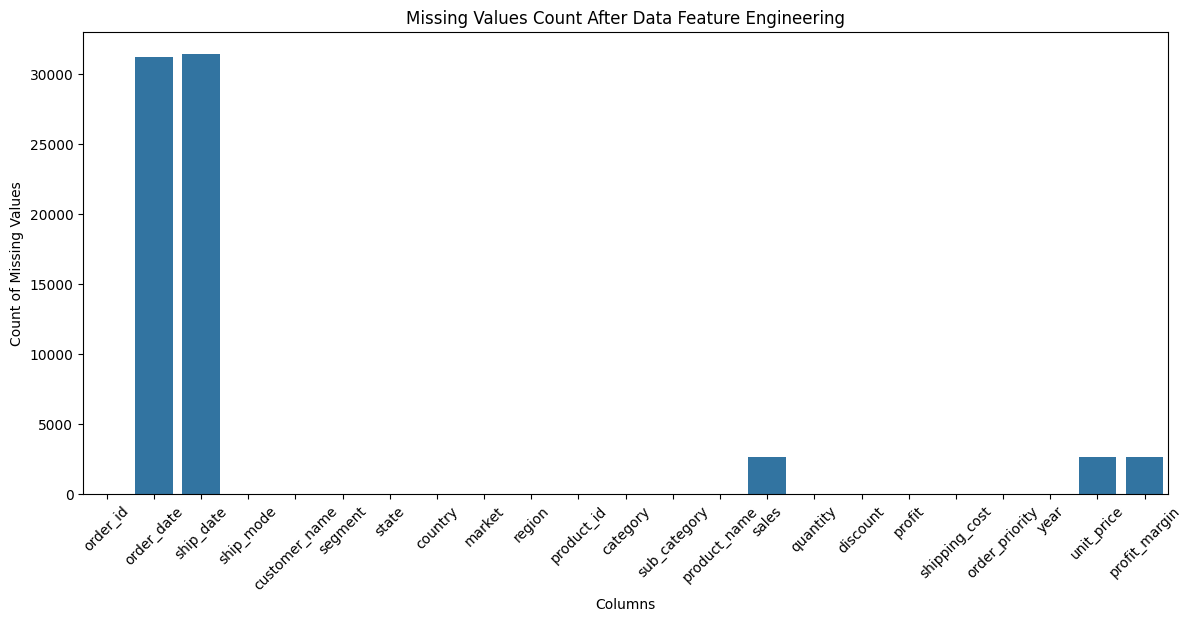

In [34]:
# Check missing values after data feature engineering
# ---- IGNORE ---
# Visualize missing values data after data feature engineering
plt.figure(figsize=(14, 6))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.title('Missing Values Count After Data Feature Engineering')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [35]:
# Handle missing values

# Imputation methods on sales, unit_price, and profit_margin columns
# 1. Impute with mean
mean_imputed_sales = df['sales'].fillna(df['sales'].mean())
mean_imputed_unit_price = df['unit_price'].fillna(df['unit_price'].mean())
mean_imputed_profit_margin = df['profit_margin'].fillna(df['profit_margin'].mean())

# 2. Impute with median
median_imputed_sales = df['sales'].fillna(df['sales'].median())
median_imputed_unit_price = df['unit_price'].fillna(df['unit_price'].median())
median_imputed_profit_margin = df['profit_margin'].fillna(df['profit_margin'].median())

# 3. Interpolate missing values with linear method
linear_interpolated_sales = df['sales'].interpolate(method='linear')
linear_interpolated_unit_price = df['unit_price'].interpolate(method='linear')
linear_interpolated_profit_margin = df['profit_margin'].interpolate(method='linear')

In [36]:
# Handle missing values for sales, unit_price, and profit_margin columns using linear interpolation
df['sales'] = linear_interpolated_sales
df['unit_price'] = linear_interpolated_unit_price
df['profit_margin'] = linear_interpolated_profit_margin

In [37]:
# Handle missing values for order_date and ship_date columns using forward fill method
df['order_date'] = df['order_date'].ffill()
df['ship_date'] = df['ship_date'].ffill()
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
unit_price        0
profit_margin     0
dtype: int64

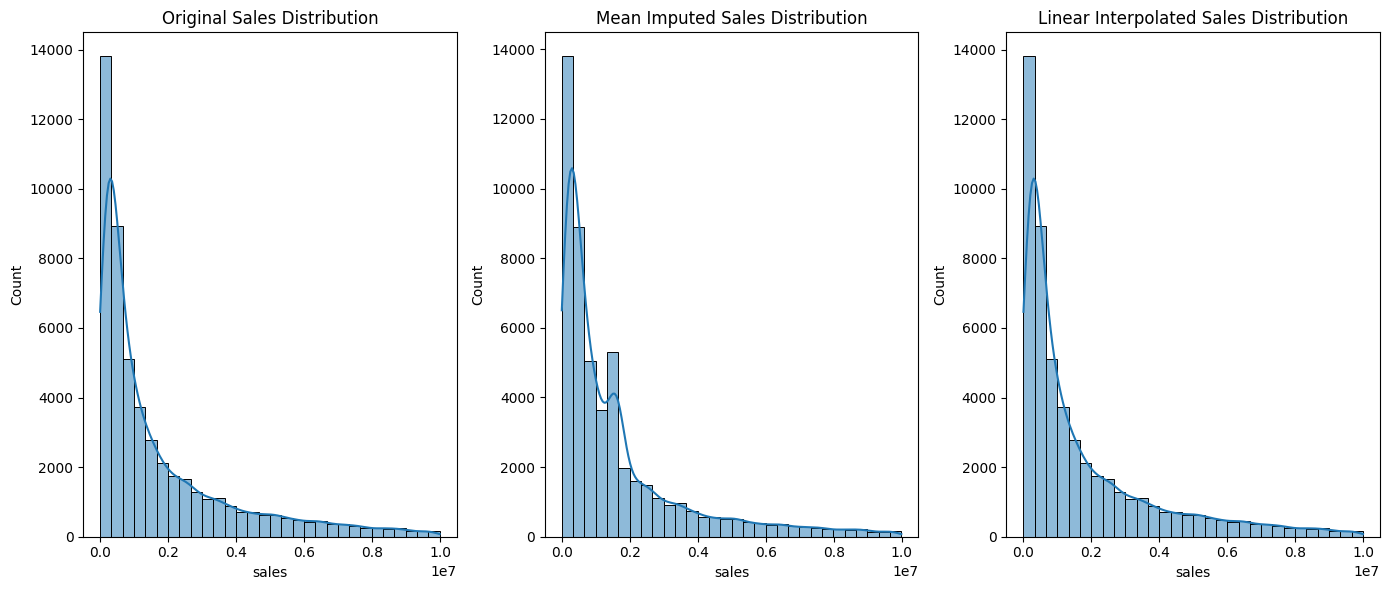

In [38]:
# visualize comparison of original sales, mean imputed sales, and linear interpolated sales
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.histplot(df['sales'], bins=30, kde=True)
plt.title('Original Sales Distribution')
plt.subplot(1, 3, 2)
sns.histplot(mean_imputed_sales, bins=30, kde=True)
plt.title('Mean Imputed Sales Distribution')
plt.subplot(1, 3, 3)
sns.histplot(linear_interpolated_sales, bins=30, kde=True)
plt.title('Linear Interpolated Sales Distribution')
plt.tight_layout()
plt.show()

## Data Visualization

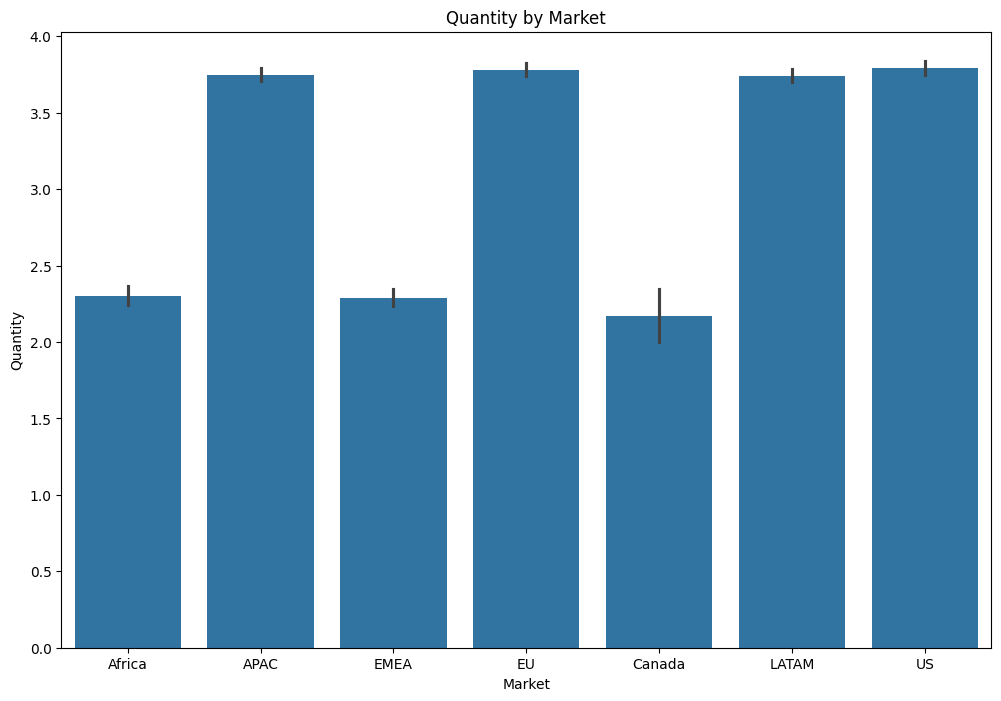

In [39]:
# Visual data for sales by category
plt.figure(figsize=(12, 8))
sns.barplot(x='market', y='quantity', data=df)
plt.title('Quantity by Market')
plt.xlabel('Market')
plt.ylabel('Quantity')
plt.show()

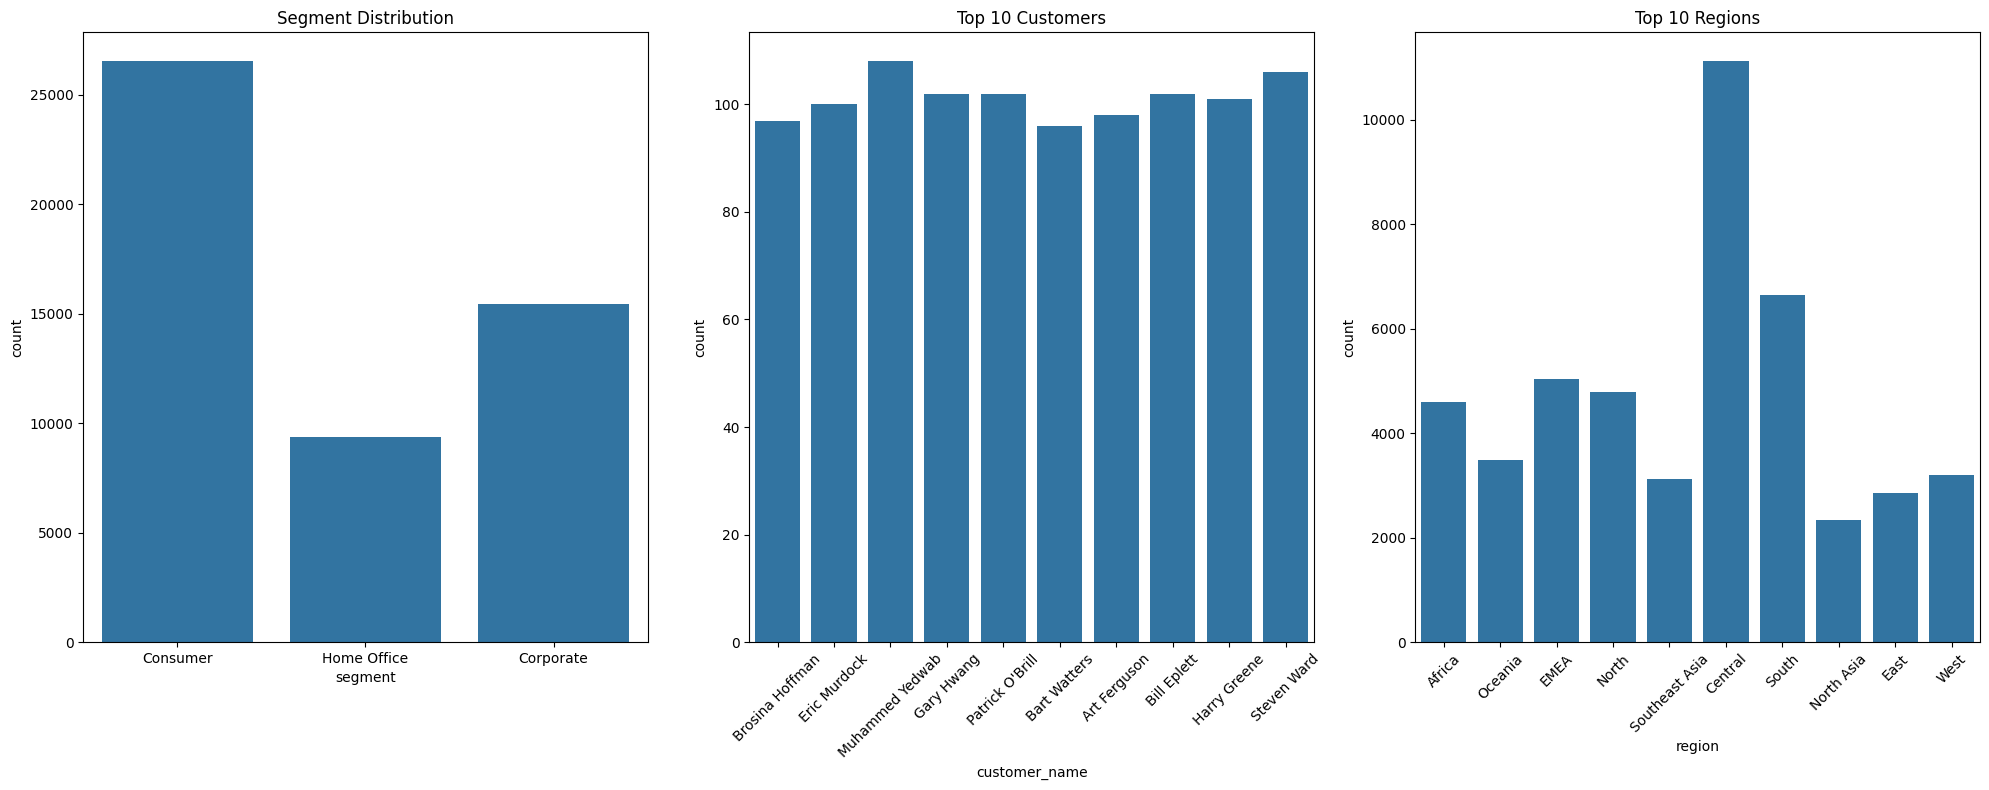

In [40]:
# Get top 10 customer_name (most frequent)
top_customers_10 = df['customer_name'].value_counts().head(10)

# Get top 10 regions (most frequent)
top_regions_10 = df['region'].value_counts().head(10)

# Data visualization for segment (user), customer_name (top 10), and region (top 10)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
sns.countplot(x='segment', data=df, ax=axes[0])
sns.countplot(x='customer_name', data=df[df['customer_name'].isin(top_customers_10.index)], ax=axes[1])
sns.countplot(x='region', data=df[df['region'].isin(top_regions_10.index)], ax=axes[2])

axes[0].set_title('Segment Distribution')
axes[1].set_title('Top 10 Customers')
axes[1].tick_params(axis='x', rotation=45)
axes[2].set_title('Top 10 Regions')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

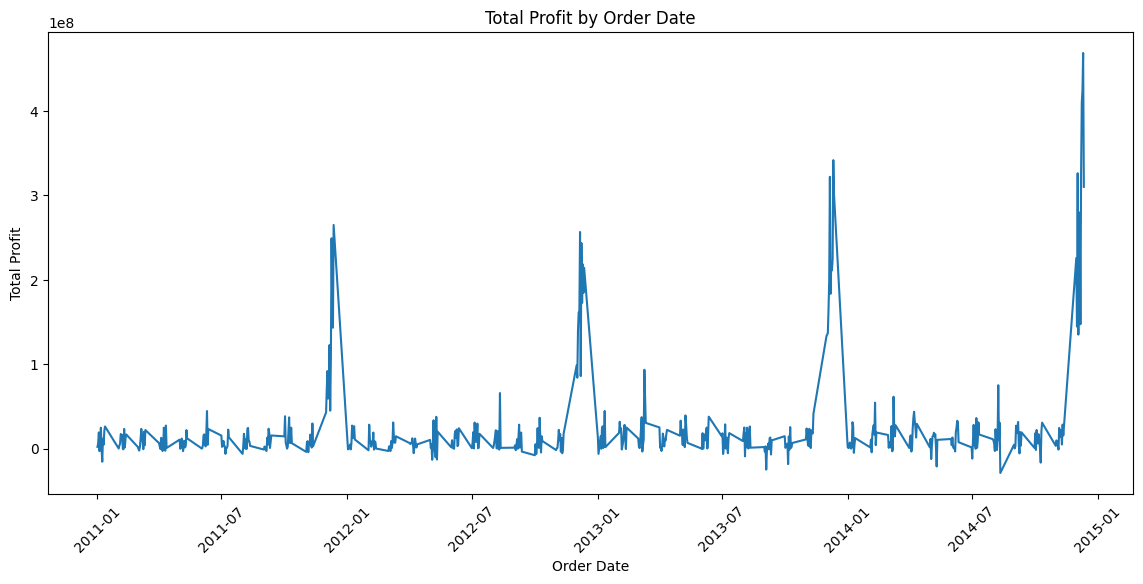

In [41]:
# Total profit by order_date
profit_by_date = df.groupby('order_date')['profit'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(profit_by_date['order_date'], profit_by_date['profit'])
plt.title('Total Profit by Order Date')
plt.xlabel('Order Date')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

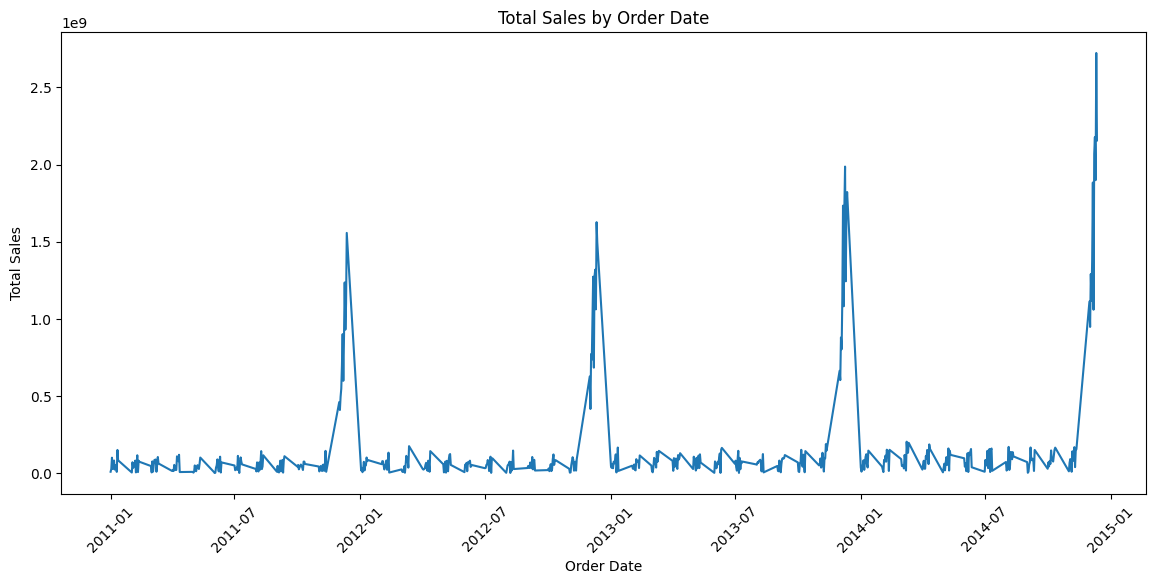

In [42]:
# Total sales by order_date
sales_by_date = df.groupby('order_date')['sales'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(sales_by_date['order_date'], sales_by_date['sales'])
plt.title('Total Sales by Order Date')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

## Drop duplicate on order_id subset

In [43]:
# Drop duplicate on subset order_id
df = df.drop_duplicates(subset=['order_id'])

## Data encoding - Data scale

In [44]:
from sklearn.preprocessing import LabelEncoder

# Copy data
df_clean = df.copy()

# Remove data isn't needed for machine learning algorithm
df_clean.drop(columns=['order_id', 'order_date', 'ship_date', 'product_id'], inplace=True)
df_clean.head()

# Encode data for categorical features
label_encoder = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = label_encoder.fit_transform(df_clean[col])

# Show data
df_clean.head()

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,3,751,0,255,2,1,0,1,14,3266,4080000.0,2,0.0,1061400.0,354600.0,3,2011,2040000.0,2600.0
1,3,398,0,701,6,0,9,1,15,154,1200000.0,3,0.1,360360.0,97200.0,3,2011,400000.0,3000.0
2,2,48,0,175,56,3,5,1,14,3235,660000.0,4,0.0,296400.0,81700.0,1,2011,165000.0,4500.0
3,2,275,2,937,123,4,7,1,12,1253,450000.0,3,0.5,-260550.0,48200.0,1,2011,150000.0,-5800.0
6,3,483,0,746,22,2,1,2,11,2541,3140000.0,1,0.0,31200.0,241000.0,3,2011,3140000.0,100.0


## Get duplicate of df to re-assign order_date

In [46]:
df_clean_features = df.copy()

# Remove data isn't needed for machine learning algorithm
df_clean_features.drop(columns=['order_id', 'product_id'], inplace=True)

# Encode data for cateorical features
label_encoder_features = LabelEncoder()
for col in df_clean_features.select_dtypes(include=['object']).columns:
    df_clean_features[col] = label_encoder_features.fit_transform(df_clean_features[col])

# Show data
df_clean_features.head()

,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,2011-01-01,2011-06-01,3,751,0,255,2,1,0,1,14,3266,4080000.0,2,0.0,1061400.0,354600.0,3,2011,2040000.0,2600.0
1,2011-01-01,2011-08-01,3,398,0,701,6,0,9,1,15,154,1200000.0,3,0.1,360360.0,97200.0,3,2011,400000.0,3000.0
2,2011-01-01,2011-05-01,2,48,0,175,56,3,5,1,14,3235,660000.0,4,0.0,296400.0,81700.0,1,2011,165000.0,4500.0
3,2011-01-01,2011-05-01,2,275,2,937,123,4,7,1,12,1253,450000.0,3,0.5,-260550.0,48200.0,1,2011,150000.0,-5800.0
6,2011-02-01,2011-06-01,3,483,0,746,22,2,1,2,11,2541,3140000.0,1,0.0,31200.0,241000.0,3,2011,3140000.0,100.0


In [47]:
df_clean_features.to_parquet("../../Production/app/data/cleaned/X_features_with_order_data.parquet", index=False)

## Divide data into X and y

In [ ]:
# Define features and target variable
X = df_clean.drop(columns=['sales'])
y = df_clean['sales']

# Force replace any hidden inf structures just in case
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)  # Fill missing values with median

# This keeps numbers within a safe, large boundary (e.g., -1 billion to 1 billion)
X = X.clip(lower=-1e9, upper=1e9)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (20028, 18)
X_test shape: (5007, 18)
y_train shape: (20028,)
y_test shape: (5007,)


In [ ]:
numeric_cols = df_clean.select_dtypes(include=np.number)
numeric_cols

# Round 2 decimal places for numeric columns
numeric_cols = numeric_cols.round(2)

# apply to the original dataframe
df_clean[numeric_cols.columns] = numeric_cols
df_clean

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,3,751,0,255,2,1,0,1,14,3266,4080000.0,2,0.0,1061400.0,354600.0,3,2011,2040000.0,2600.0
1,3,398,0,701,6,0,9,1,15,154,1200000.0,3,0.1,360360.0,97200.0,3,2011,400000.0,3000.0
2,2,48,0,175,56,3,5,1,14,3235,660000.0,4,0.0,296400.0,81700.0,1,2011,165000.0,4500.0
3,2,275,2,937,123,4,7,1,12,1253,450000.0,3,0.5,-260550.0,48200.0,1,2011,150000.0,-5800.0
6,3,483,0,746,22,2,1,2,11,2541,3140000.0,1,0.0,31200.0,241000.0,3,2011,3140000.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51281,3,264,1,192,139,6,12,1,3,1405,210000.0,2,0.2,64750.0,20600.0,3,2014,105000.0,3100.0
51282,3,316,0,1080,136,3,5,1,10,430,280000.0,4,0.0,61200.0,17000.0,3,2014,70000.0,2200.0
51284,3,402,2,962,81,5,7,1,10,2416,170000.0,3,0.0,6600.0,13200.0,3,2014,56700.0,400.0
51286,3,472,0,921,85,1,0,1,3,3383,40000.0,1,0.0,4200.0,4900.0,3,2014,40000.0,1000.0


In [ ]:
df_clean['customer_name'].value_counts()

customer_name
286    46
451    45
73     45
445    44
263    44
       ..
296    20
571    17
677    17
529    15
197    14
Name: count, Length: 795, dtype: int64

# Data scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [ ]:
X_train.head()

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
16581,3,256,1,688,101,0,11,2,0,2908,3,0.450,-769725.0,154600.0,3,2012,1410000.0,-1800.0
36035,2,170,0,192,139,6,12,1,3,1664,2,0.200,58914.0,20700.0,1,2014,85000.0,3500.0
8110,0,741,0,598,92,5,3,2,6,696,3,0.002,2647730.4,1052700.0,1,2011,2106700.0,4200.0
44392,3,215,2,253,139,6,6,1,14,1166,2,0.000,108136.0,51800.0,2,2014,195000.0,2800.0
44396,2,242,0,311,138,4,7,1,2,3127,5,0.500,-119250.0,42300.0,3,2014,66000.0,-3600.0


## Machine learning - Supervised learning to predict Sales, Profit, Risk management company

In [ ]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.validation import check_is_fitted

# Define models
models = {
    "XGBRegressor": XGBRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_jobs=-1, random_state=42),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "CatboostRegressor": CatBoostRegressor(random_state=42, verbose=0)
}

# Define parameters for RandomizedSearchCV
param_randomized = {
    "XGBRegressor": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [5, 7, 9],
        "colsample_bytree": [0.7, 0.8, 0.9]
    },
    "RandomForestRegressor": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [2, 4, 6]
    },
    "DecisionTreeRegressor": {
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [2, 5, 7]
    },
    "CatboostRegressor": {
        "iterations": [100, 200],
        "depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1, 0.2]
    }
}

# Train and evaluate each models
trained_models = {}
results = []

for model_name, model in models.items():
    print("=" * 80)
    print(f"Training {model_name}...")

    # Traditional machine learning models with hyperparameter tuning
    if len(param_randomized[model_name]) > 0:
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_randomized[model_name],
            n_iter=10,
            scoring='r2',
            cv=5,
            verbose=1,
            n_jobs=-1,
            random_state=42
        )
        random_search.fit(X_train_scaled, y_train) # Train the model with RandomizedSearchCV

        # Get the best model
        best_model = random_search.best_estimator_
        print(f"Best parameters for {model_name}: {random_search.best_params_}")

    else:
        best_model = model
        best_model.fit(X_train_scaled, y_train)
        print(f"Best parameters for {model_name}: No hyperparameters to tune.")

    # Store trained model
    trained_models[model_name] = best_model

    # Predict on test set
    y_pred = best_model.predict(X_test_scaled)

    # Keras outputs predictions as a 2D array [[p1], [p2]]. Have to flatten it to 1D for sklearn metrics.
    if model_name == "DeepLearning":
        y_pred = y_pred.flatten()

    # Calculate all metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append results to the list
    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2 Score": r2
    })

    print(f"R² Score : {r2:.3f}")
    print(f"RMSE     : {rmse:.3f}")

# Generate initial ML-only comparison dataframe
df_comparison = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("\n")
print("=" * 80)
print("Machine Learning Model Performance:")
print("=" * 80)
display(df_comparison)

Training XGBRegressor...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

## Implement sales models into dataframe

In [ ]:
df_sales_result = df_clean.copy()

for model_name, model in trained_models.items():
    sales_feature_cols = getattr(model, 'feature_names_in_', None)

    if sales_feature_cols is not None:
        X_sales = X.reindex(columns=sales_feature_cols, fill_value=0)  # Ensure the same feature columns are used
    else:
        X_sales = X.copy()  # If no feature names, use the original features

    df_sales_result[f"{model_name}_predict"] = model.predict(X_sales)

    # Get models score if available
    if hasattr(model, 'score'):
        df_sales_result[f"{model_name}_score"] = model.predict_proba(X_sales) if hasattr(model, 'predict_proba') else model.score(X_sales, y)

    # Move sales column to the last column
    sales_col = df_sales_result.pop('sales')
    df_sales_result['sales'] = sales_col

In [ ]:
df_sales_result_model = df_sales_result[["XGBRegressor_predict", "RandomForestRegressor_predict", "DecisionTreeRegressor_predict", "CatboostRegressor_predict", "sales", "XGBRegressor_score", "RandomForestRegressor_score", "DecisionTreeRegressor_score", "CatboostRegressor_score"]]

In [ ]:
df_sales_result_model.sample(20)

,XGBRegressor_predict,RandomForestRegressor_predict,DecisionTreeRegressor_predict,CatboostRegressor_predict,sales,XGBRegressor_score,RandomForestRegressor_score,DecisionTreeRegressor_score,CatboostRegressor_score
43264,4730324.00,6.290114e+06,6.614630e+06,4.693454e+06,6360000.00,-1.311505,-2.855382,-3.129844,-1.583854
39756,4469471.50,6.253192e+06,6.614630e+06,4.747237e+06,650000.00,-1.311505,-2.855382,-3.129844,-1.583854
20612,4675539.00,6.258362e+06,6.614630e+06,4.710794e+06,2310000.00,-1.311505,-2.855382,-3.129844,-1.583854
643,4719178.00,6.268478e+06,6.614630e+06,4.807360e+06,160000.00,-1.311505,-2.855382,-3.129844,-1.583854
22232,4595769.00,6.281088e+06,6.614630e+06,4.525395e+06,1250000.00,-1.311505,-2.855382,-3.129844,-1.583854
42607,4518799.00,6.130369e+06,6.614630e+06,4.185305e+06,1590000.00,-1.311505,-2.855382,-3.129844,-1.583854
27016,4598074.50,6.272162e+06,6.614630e+06,5.572050e+06,8920000.00,-1.311505,-2.855382,-3.129844,-1.583854
5497,4472773.00,6.261693e+06,6.614630e+06,5.576447e+06,3040000.00,-1.311505,-2.855382,-3.129844,-1.583854
47880,6408762.50,7.041459e+06,6.614630e+06,5.747064e+06,2750000.00,-1.311505,-2.855382,-3.129844,-1.583854
7906,4730698.50,6.278947e+06,6.614630e+06,5.563881e+06,1360000.00,-1.311505,-2.855382,-3.129844,-1.583854


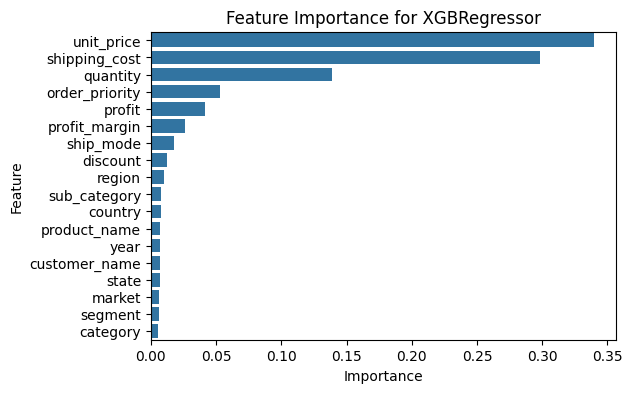

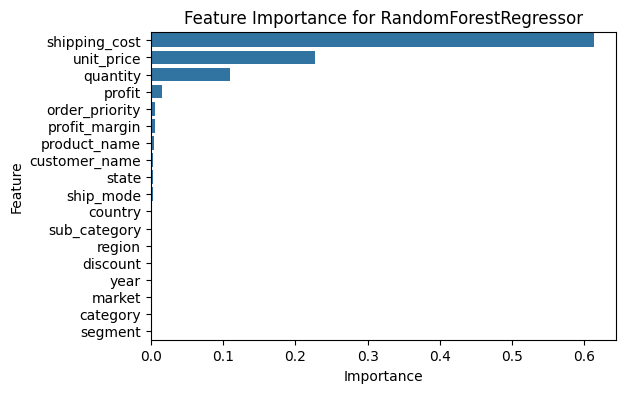

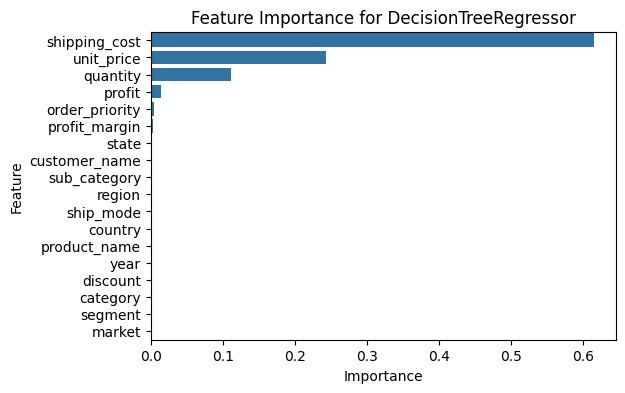

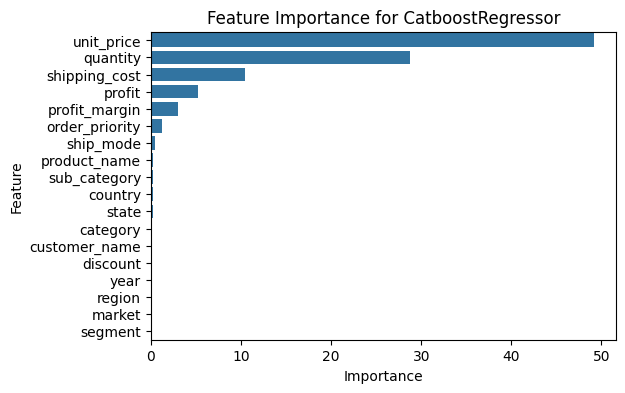

In [ ]:
# Feature importance for all models

for model_name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
        feature_names = X.columns
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(6, 4))
        sns.barplot(x='Importance', y='Feature', data=importance_df)
        plt.title(f'Feature Importance for {model_name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    else:
        print(f"{model_name} does not have feature importances.")

In [ ]:
# Apply log transformation to handle skewness
y_train_log = np.log1p(y_train)

# Initialize a clean evaluation Dataframe aligned
df_eval = pd.DataFrame(index=y_test.index)
df_eval['Actual_Sales'] = y_test

# Loop through all trained models to predict and evaluate
for model_name, model in trained_models.items():
    print("=" * 80)
    print(f"Retraining {model_name} with log-transformed target variable...")

    model.fit(X_train_scaled, y_train_log)
    
    y_pred_log = model.predict(X_test_scaled)
    y_pred_actual = np.expm1(y_pred_log)  # Reverse log transformation

    # Add predictions dynamically to the evaluation DataFrame
    df_eval[f"{model_name}_Predict"] = y_pred_actual
    
    # Calculate row-by-row variance metrics for this model
    df_eval[f"{model_name}_Abs_Error"] = abs(df_eval['Actual_Sales'] - df_eval[f"{model_name}_Predict"])
    df_eval[f"{model_name}_Error_Pct %"] = (df_eval[f"{model_name}_Abs_Error"] / df_eval['Actual_Sales']) * 100

    print(f"✔ {model_name} processing complete.")

print("\n" + "=" * 80)
print("All models successfully retrained and evaluated! 🚀")
print("=" * 80)

Retraining XGBRegressor with log-transformed target variable...
✔ XGBRegressor processing complete.
Retraining RandomForestRegressor with log-transformed target variable...
✔ RandomForestRegressor processing complete.
Retraining DecisionTreeRegressor with log-transformed target variable...
✔ DecisionTreeRegressor processing complete.
Retraining CatboostRegressor with log-transformed target variable...
✔ CatboostRegressor processing complete.

All models successfully retrained and evaluated! 🚀


In [ ]:
df_eval[['Actual_Sales', 'XGBRegressor_Predict', 'RandomForestRegressor_Predict', 'DecisionTreeRegressor_Predict', 'CatboostRegressor_Predict', 'XGBRegressor_Abs_Error', 'RandomForestRegressor_Abs_Error', 'DecisionTreeRegressor_Abs_Error', 'CatboostRegressor_Abs_Error', 'XGBRegressor_Error_Pct %', 'RandomForestRegressor_Error_Pct %', 'DecisionTreeRegressor_Error_Pct %', 'CatboostRegressor_Error_Pct %']].sample(20)

,Actual_Sales,XGBRegressor_Predict,RandomForestRegressor_Predict,DecisionTreeRegressor_Predict,CatboostRegressor_Predict,XGBRegressor_Abs_Error,RandomForestRegressor_Abs_Error,DecisionTreeRegressor_Abs_Error,CatboostRegressor_Abs_Error,XGBRegressor_Error_Pct %,RandomForestRegressor_Error_Pct %,DecisionTreeRegressor_Error_Pct %,CatboostRegressor_Error_Pct %
22734,4.656667e+06,4.608883e+06,5.082776e+06,4.749955e+06,5.066822e+06,4.778367e+04,4.261089e+05,9.328827e+04,4.101552e+05,1.026135,9.150512e+00,2.003327e+00,8.807913
39663,1.010000e+06,1.064839e+06,1.061291e+06,1.143041e+06,9.651189e+05,5.483888e+04,5.129088e+04,1.330407e+05,4.488111e+04,5.429592,5.078305e+00,1.317234e+01,4.443675
34059,4.900000e+05,4.968777e+05,4.900000e+05,4.900000e+05,4.982750e+05,6.877719e+03,6.984919e-09,4.365575e-09,8.275034e+03,1.403616,1.425494e-12,8.909336e-13,1.688782
26582,1.990000e+06,2.087339e+06,1.955662e+06,1.975959e+06,1.971100e+06,9.733912e+04,3.433800e+04,1.404092e+04,1.890027e+04,4.891413,1.725528e+00,7.055737e-01,0.949762
23961,1.060000e+06,1.005856e+06,1.051388e+06,1.045740e+06,1.007210e+06,5.414438e+04,8.611522e+03,1.425986e+04,5.278971e+04,5.107960,8.124077e-01,1.345270e+00,4.980161
36637,4.580000e+06,4.669464e+06,4.445144e+06,3.897639e+06,4.555295e+06,8.946350e+04,1.348557e+05,6.823613e+05,2.470547e+04,1.953352,2.944447e+00,1.489872e+01,0.539421
21674,1.330000e+06,1.327083e+06,1.327385e+06,1.349946e+06,1.363775e+06,2.917125e+03,2.614506e+03,1.994602e+04,3.377537e+04,0.219333,1.965794e-01,1.499701e+00,2.539502
33910,5.700000e+05,5.395914e+05,5.706472e+05,5.636159e+05,5.719969e+05,3.040862e+04,6.471919e+02,6.384099e+03,1.996936e+03,5.334846,1.135424e-01,1.120017e+00,0.350340
2894,2.060000e+06,2.125328e+06,2.062414e+06,2.065440e+06,2.188598e+06,6.532775e+04,2.413599e+03,5.439692e+03,1.285981e+05,3.171250,1.171650e-01,2.640627e-01,6.242627
40096,8.300000e+05,8.837468e+05,8.649520e+05,8.602986e+05,8.652401e+05,5.374675e+04,3.495200e+04,3.029859e+04,3.524015e+04,6.475512,4.211084e+00,3.650432e+00,4.245801


## Save models

In [ ]:
import os
import joblib
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# 1. Create a dedicated output directory
OUTPUT_DIR = Path.cwd().parent / "Models" / "sales_ml_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("Saving Updated Machine Learning Models...")
print("=" * 80)
    
# 2. Save each model dynamically using joblib
for model_name, model in trained_models.items():
    model_path = OUTPUT_DIR / f"{model_name}_model.joblib"
    joblib.dump(model, model_path)
    print(f"✔ Saved {model_name} to: {model_path}")

print("\n" + "=" * 80)
print("Calculating and Saving Overall Performance Metrics...")
print("=" * 80)

# 3. Calculate global evaluation metrics for the log-scaled models
updated_results = []

for model_name in trained_models.keys():
    # Pull the predictions from our df_eval dataframe
    y_pred_actual = df_eval[f'{model_name}_Predict']
    
    # Calculate overall metrics on actual scale
    mse = mean_squared_error(y_test, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_actual)
    mape = mean_absolute_percentage_error(y_test, y_pred_actual)
    r2 = r2_score(y_test, y_pred_actual)
    
    updated_results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2 Score": r2
    })

# 4. Generate the final comparison summary dataframe
df_comparison_final = pd.DataFrame(updated_results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

# 5. Export summary and row-by-row dataframes to CSV files
summary_csv_path = OUTPUT_DIR / "model_comparison_summary.csv"
predictions_csv_path = OUTPUT_DIR / "row_by_row_predictions.csv"

# Save scaler
scaler_path = OUTPUT_DIR / "scaler.joblib"
joblib.dump(scaler, scaler_path)

df_comparison_final.to_csv(summary_csv_path, index=False)
df_eval.to_csv(predictions_csv_path, index=True) # keeps the original y_test indices

print(f"✔ Saved summary leaderboard to: {summary_csv_path}")
print(f"✔ Saved row-by-row predictions table to: {predictions_csv_path}")
print("\n" + "=" * 80)
print("Final Summary Leaderboard:")
print("=" * 80)
display(df_comparison_final)

## Save params

In [ ]:
import json
from pathlib import Path

SALES_OUTPUT_DIR = Path.cwd().parent / "Models" / "sales_ml_models" / "artifacts"
SALES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sales_params_path = SALES_OUTPUT_DIR / "sales_model_params.json"

sales_params = []
for model_name, model in trained_models.items():
    sales_params.append({
        "Model": model_name,
        "Params": model.get_params()
    })

with open(sales_params_path, "w", encoding="utf-8") as f:
    json.dump(sales_params, f, indent=2, default=str)

print(f"Saved sales params to: {sales_params_path}")

Saved sales params to: /Users/miftahhadiyannoor/Documents/Supermarket_Sales/Production/Models/sales_ml_models/artifacts/sales_model_params.json
